In [2]:
import pandas as pd
import plotly.graph_objects as go
import math

# 1. 로컬 데이터 로드 및 전처리
csv_path = r"C:\Users\user\SLM\02_cuda_aligned\all_logs\evaluation_results_full.csv"
df = pd.read_csv(csv_path)

# [핵심 수정] Perplexity 열을 강제로 숫자형(Float)으로 변환하여 Y축 폭증 버그 해결
df['Perplexity'] = pd.to_numeric(df['Perplexity'], errors='coerce')

# 비트 레벨 정제 및 X축 정렬 순서 정의
bit_mapping = {
    '16-bit': '16-bit (Base)',
    'GPTQ_8bit': '8-bit',
    'GPTQ_4bit': '4-bit',
    'GPTQ_3bit': '3-bit',
    'GPTQ_2bit': '2-bit'
}
df['Bit_Level_Clean'] = df['Bit_Level'].map(bit_mapping)

# 역순 정렬을 위한 범주형(Categorical) 데이터 설정
bit_order = ['16-bit (Base)', '8-bit', '4-bit', '3-bit', '2-bit']
df['Bit_Level_Clean'] = pd.Categorical(df['Bit_Level_Clean'], categories=bit_order, ordered=True)
df = df.sort_values('Bit_Level_Clean')

# 2. 색상 매핑
color_map = {
    'Llama_3.2_1B': '#5A9BD5',    
    'TinyLlama_1.1B': '#E67E22',   
    'Qwen2.5_1.5B': '#9B59B6'
}

# 3. Plotly Figure 생성 및 데이터 매핑
fig = go.Figure()

for model_name in color_map.keys():
    model_data = df[df['Model_Family'] == model_name]
    if not model_data.empty:
        fig.add_trace(go.Scatter(
            x=model_data['Bit_Level_Clean'],
            y=model_data['Perplexity'],
            mode='lines+markers',
            name=model_name,
            line=dict(color=color_map[model_name], width=2.5)
        ))

# 4. 마커 스타일링 (요청하신 로직 완벽 적용)
for trace in fig.data:
    if isinstance(trace, go.Scatter):
        trace.update(
            marker=dict(
                symbol='circle',
                color='white',
                size=9, 
                line=dict(color=trace.line.color, width=2.5)
            ),
            line=dict(width=2.5)
        )

# 5. 레이아웃 및 축 설정
fig.update_layout(
    title=dict(
        text='<b>극한의 양자화 환경에 따른 PPL 붕괴 양상</b>',
        font=dict(size=22),
        x=0.5,
        xanchor='center'
    ),
    xaxis_title='<b>양자화 정밀도 (Bit-width)</b>',
    yaxis_title='<b>Perplexity (PPL, Log10 Scale) - 낮을수록 우수</b>',
    yaxis_type='log',  # Y축 로그 스케일 변환

    yaxis=dict(
        tickformat=",.0f",  # 소수점을 없애고 천 단위 콤마(,)를 찍어주는 포맷
        dtick=1
    ),
    template='plotly_white',
    legend=dict(
        title='<b>모델 체급</b>',
        x=0.02,
        y=0.98,
        bgcolor='rgba(255, 255, 255, 0.9)',
        bordercolor='lightgray',
        borderwidth=1
    ),
    hovermode='x unified',
    margin=dict(l=60, r=60, t=80, b=60)
)

# 6. 주석 및 강조 요소 추가

# 4-bit 위치 강조를 위한 세로선
fig.add_vline(x='4-bit', line_width=2, line_dash='dash', line_color='gray', opacity=0.6)

# # '4-bit 스위트 스팟' 박스 형태 주석 추가
# # Plotly의 로그 스케일에서는 y축 주석 위치를 math.log10(실제값)으로 줘야 정확히 위치합니다.
# fig.add_annotation(
#     x='4-bit',
#     y=math.log10(100),  # 시각적으로 적절한 Y축 위치 (PPL 100 언저리)
#     text='<b>4-bit 스위트 스팟<br>(가성비 역전 구간)</b>',
#     showarrow=True,
#     arrowhead=2,
#     arrowsize=1,
#     arrowwidth=2,
#     arrowcolor='gray',
#     ax=70,  # 화살표 x 오프셋
#     ay=-50, # 화살표 y 오프셋
#     bordercolor='gray',
#     borderwidth=1.5,
#     borderpad=8,
#     bgcolor='white',
#     font=dict(size=13, color='black')
# )

# 2-bit 붕괴 지점(Llama 3.2) 강조 텍스트 추가
fig.add_annotation(
    x='2-bit',
    y=math.log10(13851.76), # Llama 3.2의 실제 PPL 수치
    text='<b>Llama 3.2 구조적 붕괴<br>(PPL: 13,851)</b>',
    showarrow=True,
    arrowhead=2,
    arrowsize=1,
    arrowwidth=2,
    arrowcolor='#5A9BD5',
    ax=-80,
    ay=50,
    bordercolor='#5A9BD5',
    borderwidth=1,
    borderpad=5,
    bgcolor='white',
    font=dict(size=12, color='#5A9BD5')
)

# 7. 그래프 출력
fig.show()

ModuleNotFoundError: No module named 'plotly'

In [1]:
import pandas as pd
import plotly.graph_objects as go

# 1. 로컬 데이터 로드 및 전처리
csv_path = r"C:\Users\user\SLM\02_cuda_aligned\all_logs\evaluation_results_full.csv"
df = pd.read_csv(csv_path)

# Perplexity 열을 강제로 숫자형(Float)으로 변환
df['Perplexity'] = pd.to_numeric(df['Perplexity'], errors='coerce')

# 비트 레벨 정제 및 맵핑
bit_mapping = {
    '16-bit': '16-bit (Base)',
    'GPTQ_8bit': '8-bit',
    'GPTQ_4bit': '4-bit',
    'GPTQ_3bit': '3-bit',
    'GPTQ_2bit': '2-bit'
}
df['Bit_Level_Clean'] = df['Bit_Level'].map(bit_mapping)

# [수정 1] 16, 8, 4비트 데이터만 필터링
target_bits = ['16-bit (Base)', '8-bit', '4-bit']
df = df[df['Bit_Level_Clean'].isin(target_bits)].copy()

# 범주형(Categorical) 데이터 설정 및 정렬
df['Bit_Level_Clean'] = pd.Categorical(df['Bit_Level_Clean'], categories=target_bits, ordered=True)
df = df.sort_values('Bit_Level_Clean')

# 2. 색상 매핑
color_map = {
    'Llama_3.2_1B': '#5A9BD5',    
    'TinyLlama_1.1B': '#E67E22',   
    'Qwen2.5_1.5B': '#9B59B6'
}

# 3. Plotly Figure 생성 및 데이터 매핑
fig = go.Figure()

for model_name in color_map.keys():
    model_data = df[df['Model_Family'] == model_name]
    if not model_data.empty:
        fig.add_trace(go.Scatter(
            x=model_data['Bit_Level_Clean'],
            y=model_data['Perplexity'],
            mode='lines+markers+text', # 값 표시를 위해 text 추가 가능
            name=model_name,
            line=dict(color=color_map[model_name], width=3) # 선 굵기 살짝 강화
        ))

# 4. 마커 스타일링
for trace in fig.data:
    if isinstance(trace, go.Scatter):
        trace.update(
            marker=dict(
                symbol='circle',
                color='white',
                size=10, 
                line=dict(color=trace.line.color, width=2.5)
            ),
            line=dict(width=3)
        )

# 5. 레이아웃 및 축 설정
fig.update_layout(
    width=600,
    title=dict(
        text='<b>16~4-bit PPL 미세 변동 분석</b>',
        font=dict(size=22),
        x=0.5,
        xanchor='center'
    ),
    xaxis_title='<b>양자화 정밀도 (Bit-width)</b>',
    # [수정 2] 로그 스케일 해제 및 단위 설명 변경
    yaxis_title='<b>Perplexity (PPL, Linear Scale) - 낮을수록 우수</b>',
    yaxis=dict(
        tickformat=".1f",  # 미세한 차이를 보기 위해 소수점 첫째 자리까지 표시
        gridcolor='lightgray',
        gridwidth=0.5
    ),
    template='plotly_white',
    legend=dict(
        title='<b>모델 체급</b>',
        x=0.02,
        y=0.98,
        bgcolor='rgba(255, 255, 255, 0.9)',
        bordercolor='lightgray',
        borderwidth=1
    ),
    hovermode='x unified',
    margin=dict(l=60, r=60, t=80, b=60)
)

# 6. 주석 및 강조 요소 추가

# 4-bit 위치 강조를 위한 세로선
fig.add_vline(x='4-bit', line_width=2, line_dash='dash', line_color='gray', opacity=0.6)

# # '4-bit 스위트 스팟' 박스 형태 주석 추가
# # [수정 3] 선형 스케일에 맞게 Y축 위치(math.log10 제거) 조정
# fig.add_annotation(
#     x='4-bit',
#     y=22,  # 선형 스케일 기준 (Llama가 ~36, 나머지가 ~8~16이므로 중앙 빈 공간 배치)
#     text='<b>4-bit 스위트 스팟<br>(가성비 역전 구간)</b>',
#     showarrow=True,
#     arrowhead=2,
#     arrowsize=1,
#     arrowwidth=2,
#     arrowcolor='gray',
#     ax=-90,  # 화살표 x 오프셋 (텍스트와 겹치지 않게 방향 변경)
#     ay=0,    # 화살표 y 오프셋
#     bordercolor='gray',
#     borderwidth=1.5,
#     borderpad=8,
#     bgcolor='white',
#     font=dict(size=13, color='black')
# )

# 7. 그래프 출력
fig.show()

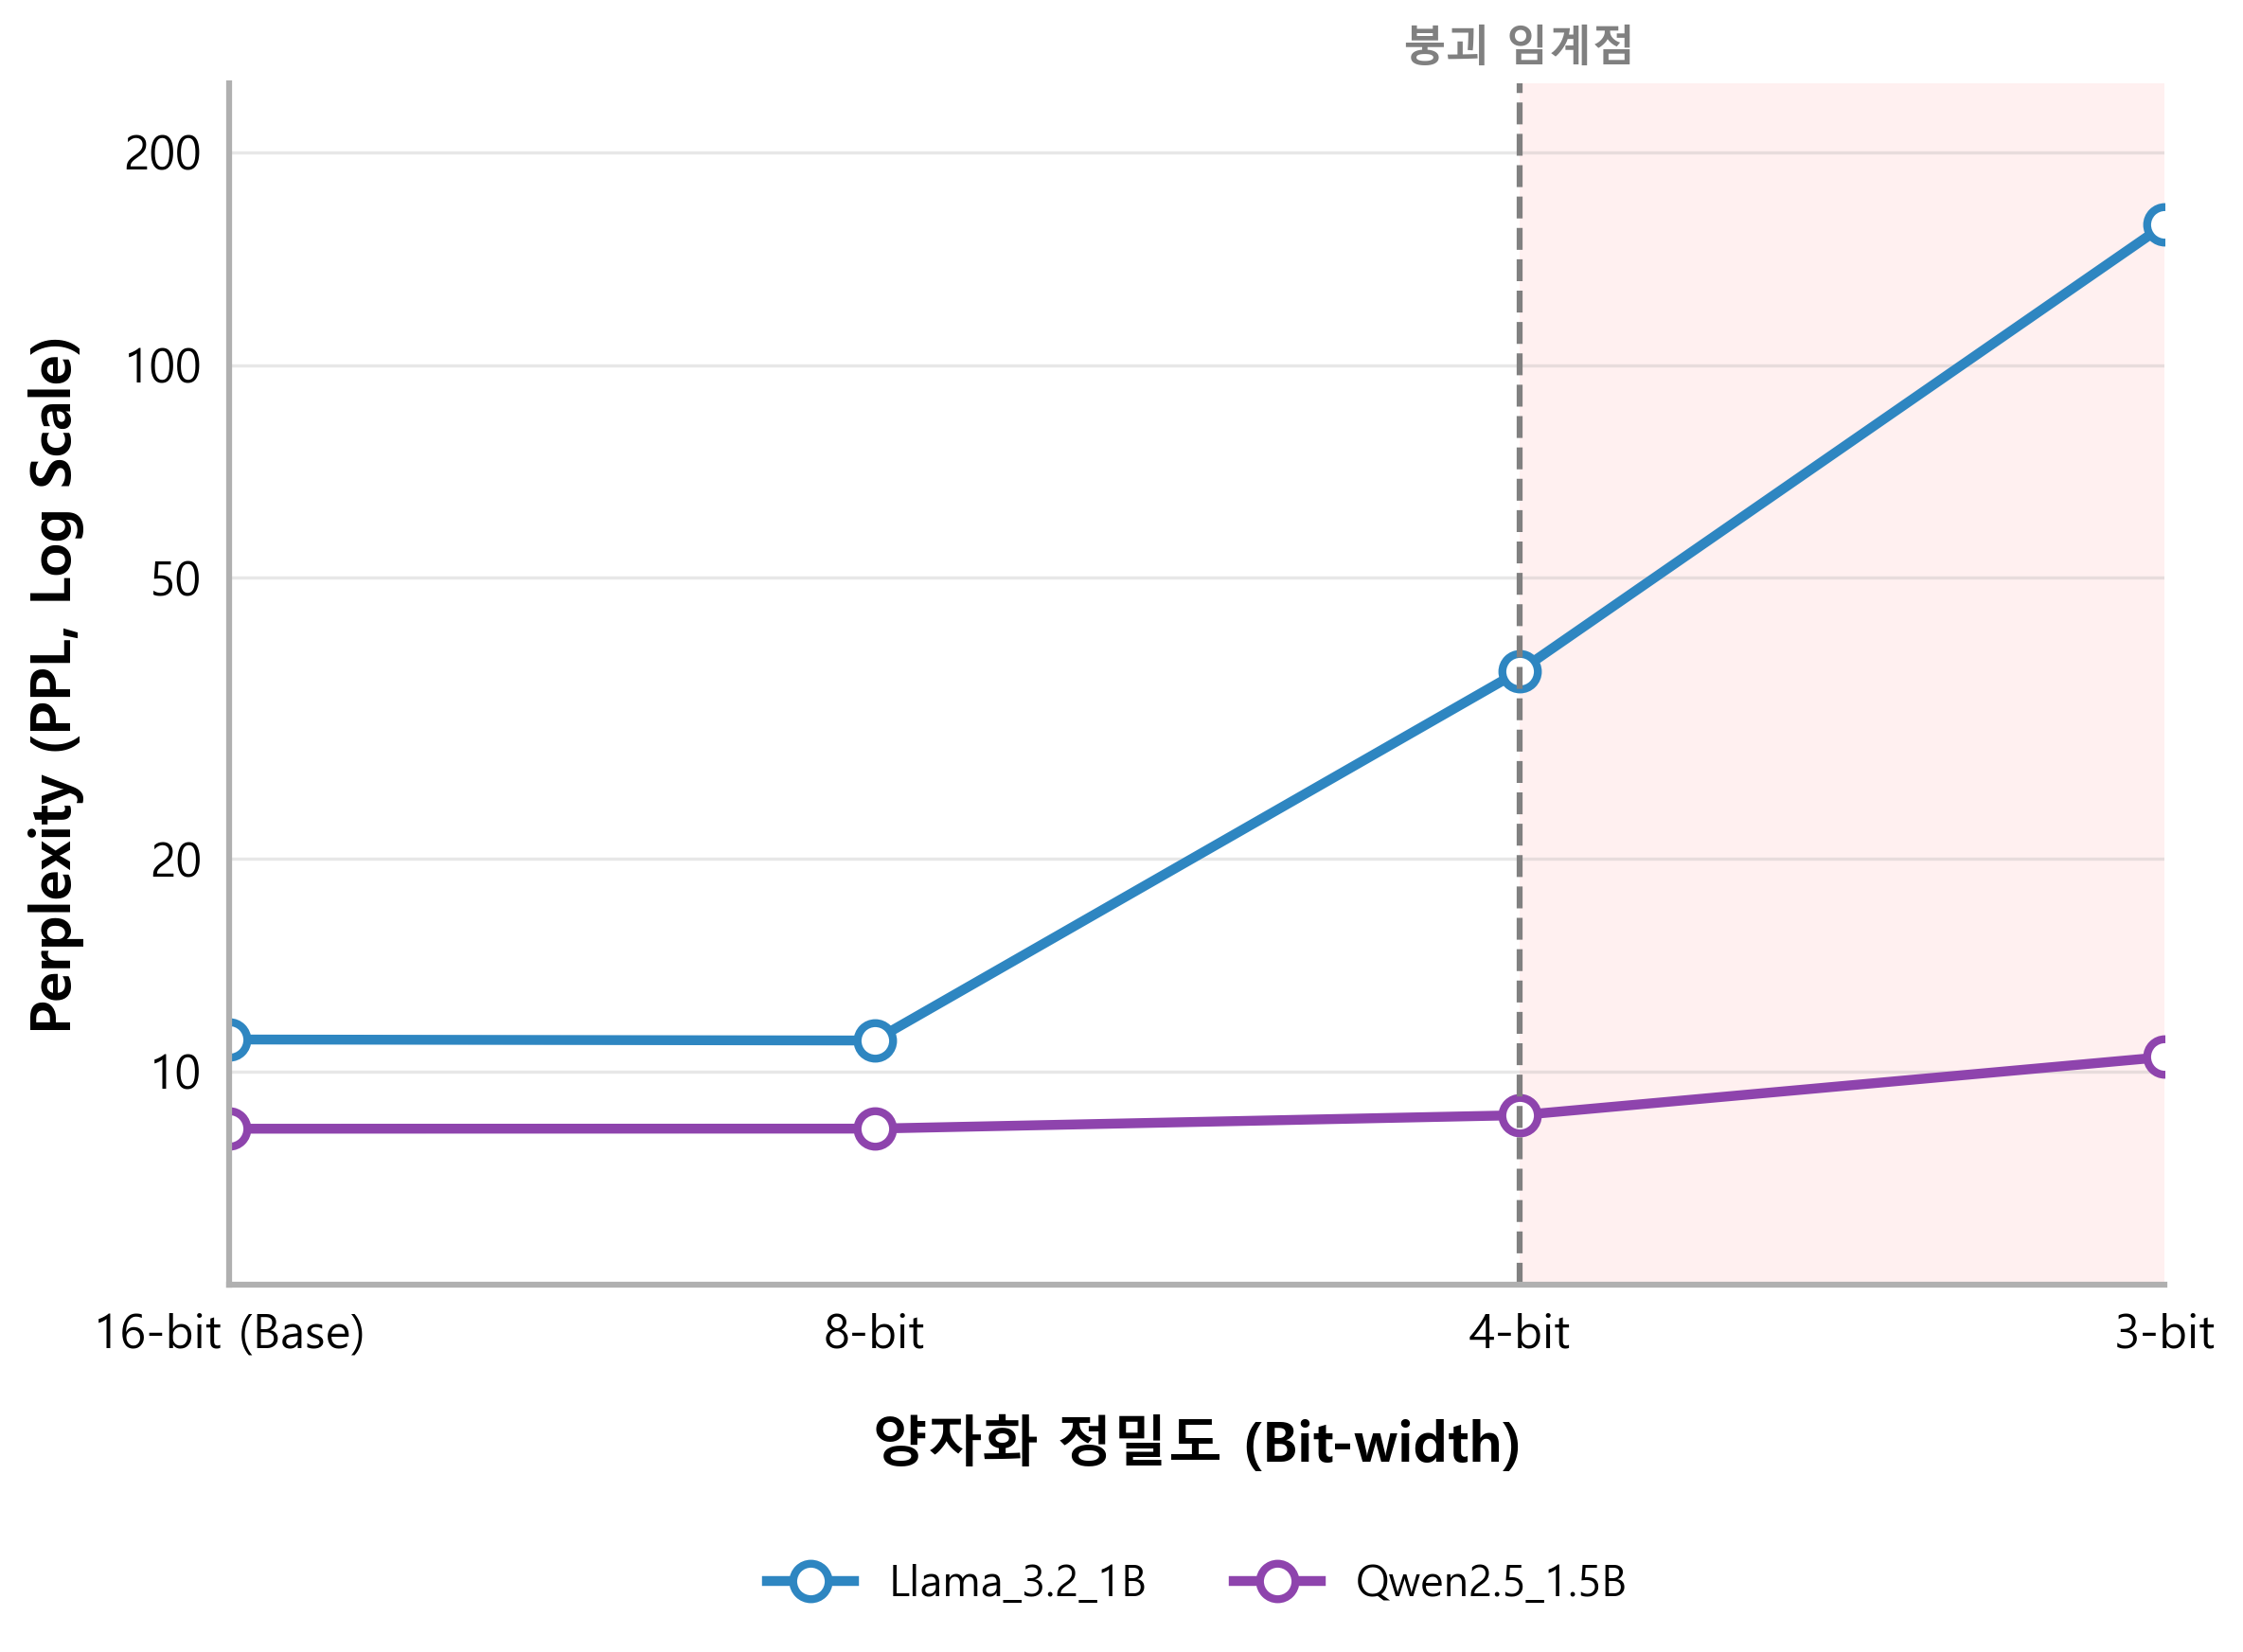

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.font_manager as fm
import os

# ---------------------------------------------------------
# 1. 폰트 설정 (한글 깨짐 완벽 해결)
# ---------------------------------------------------------
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False 

plt.rcParams['axes.titlesize'] = 16
plt.rcParams['axes.labelsize'] = 14
plt.rcParams['xtick.labelsize'] = 12
plt.rcParams['ytick.labelsize'] = 12
plt.rcParams['legend.fontsize'] = 11

# ---------------------------------------------------------
# 2. 데이터 로드 및 전처리
# ---------------------------------------------------------
csv_path = r"D:\slm-gptq-collapse-analysis\02_cuda_aligned\all_logs\evaluation_results_full.csv"
df = pd.read_csv(csv_path)

df['Perplexity'] = pd.to_numeric(df['Perplexity'], errors='coerce')
df.replace([np.inf, -np.inf], np.nan, inplace=True)

bit_mapping = {
    '16-bit': '16-bit (Base)', 'GPTQ_8bit': '8-bit',
    'GPTQ_4bit': '4-bit', 'GPTQ_3bit': '3-bit'
}
df['Bit_Level_Clean'] = df['Bit_Level'].map(bit_mapping)

target_bits = ['16-bit (Base)', '8-bit', '4-bit', '3-bit']
target_models = ['Llama_3.2_1B', 'Qwen2.5_1.5B']

df = df[df['Bit_Level_Clean'].isin(target_bits) & df['Model_Family'].isin(target_models)].copy()
df['Bit_Level_Clean'] = pd.Categorical(df['Bit_Level_Clean'], categories=target_bits, ordered=True)
df = df.sort_values('Bit_Level_Clean')

color_map = {
    'Llama_3.2_1B': '#2E86C1',  
    'Qwen2.5_1.5B': '#8E44AD'   
}

# ---------------------------------------------------------
# 3. 그래프 캔버스 생성 및 Seaborn 라인 플롯
# ---------------------------------------------------------
fig, ax = plt.subplots(figsize=(8, 6), dpi=300) 

for model_name, color in color_map.items():
    model_data = df[df['Model_Family'] == model_name]
    if not model_data.empty:
        ax.plot(
            model_data['Bit_Level_Clean'], 
            model_data['Perplexity'], 
            marker='o', markersize=9, 
            linewidth=2.5, color=color, 
            markeredgecolor=color, markeredgewidth=2, markerfacecolor='white',
            label=model_name
        )

# ---------------------------------------------------------
# 4. 축 스케일 및 디자인 튜닝 (Y축 범위 제한)
# ---------------------------------------------------------
ax.set_yscale('log')
ax.set_ylim(bottom=5, top=250) 

from matplotlib.ticker import FixedLocator, ScalarFormatter
ax.yaxis.set_major_locator(FixedLocator([10, 20, 50, 100, 200]))
formatter = ScalarFormatter()
formatter.set_scientific(False)
ax.yaxis.set_major_formatter(formatter)

# X축 라벨 여백을 약간 넓혀 범례와의 간격 확보
ax.set_xlabel('양자화 정밀도 (Bit-width)', fontweight='bold', labelpad=15)
ax.set_ylabel('Perplexity (PPL, Log Scale)', fontweight='bold', labelpad=10)

# 상단, 우측 선 제거
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# 좌측, 하단 선(그래프 틀)을 회색으로 변경 및 선 굵기 유지
spine_color = '#B0B0B0'  # 시각적으로 이질감이 없는 중간 밝기의 회색
ax.spines['left'].set_color(spine_color)
ax.spines['bottom'].set_color(spine_color)
ax.spines['left'].set_linewidth(1.5)
ax.spines['bottom'].set_linewidth(1.5)

# 눈금(Tick) 표시 제거 (라벨 텍스트는 유지됨)
ax.tick_params(bottom=False, left=False)

ax.grid(axis='y', linestyle='-', alpha=0.3) 
ax.yaxis.set_minor_locator(plt.NullLocator())
ax.set_xlim(0, 3)

# 범례(Legend) 하단 배치 설정
legend = ax.legend(
    loc='upper center', 
    bbox_to_anchor=(0.5, -0.2), # 그래프 하단 중앙 영역으로 좌표 이동
    ncol=2,                     # 2열 구성 (수평 나열)
    frameon=False               # 테두리 상자 제거
)

# ---------------------------------------------------------
# 5. 시각적 강조 (환각 분기점 표시)
# ---------------------------------------------------------
ax.axvspan(2, 3, color='red', alpha=0.06, lw=0)

ax.axvline(x=2, color='gray', linestyle='--', linewidth=1.5)
ax.text(2, 260, '붕괴 임계점', color='gray', fontweight='bold', ha='center', va='bottom', fontsize=11)

# ---------------------------------------------------------
# 6. 고해상도 이미지 저장 및 출력
# ---------------------------------------------------------
plt.tight_layout()
plt.savefig("defense_ppl_graph_matplotlib.png", dpi=300, bbox_inches='tight', facecolor='white')
plt.show()